# Extra baselines — Sven vs the full optimizer suite

Best configuration per optimizer on the headline scans, **all** baselines included, selected
by seed-mean final **validation** loss like everywhere else.  Every configuration is scored by its
**seed-mean** final loss (diverged runs excluded and counted; A4), with the clipped seed
error bar (A5).  `METRIC` picks the loss used for both selection and display.

The earlier version of this notebook was run on separate `rebuttal_baselines_*` result
directories; those runs now live in the headline scans, which this notebook loads.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import scan_analysis as sa
from style import set_style, clipped_yerr, method_color, DATASET_TITLES, metric_label

set_style()

In [2]:
# METRIC: selection (and the bars) use the final VALIDATION loss, like every other notebook; the
# table shows the train loss of the same configs alongside.
METRIC = 'final_val_loss'
PLOT_DIR = Path('plots_v2/baselines')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SCANS = {key: (name, DATASET_TITLES[key]) for key, name in [
    ('toy_1d', 'toy_1d_scan'), ('polynomial', 'polynomial_scan'),
    ('mnist_labelreg', 'mnist_scan_labelRegression'), ('mnist_ce', 'mnist_scan_ce')]}
scans, tables = {}, {}
for key, (name, title) in SCANS.items():
    try:
        scans[key] = sa.load_scan(name, title, PLOT_DIR, metric=METRIC)
    except FileNotFoundError:
        print(f'  [skip] {name}: not found')
        continue
    tables[key] = sa.summary_table(scans[key], metric=METRIC)   # baselines=None -> every optimizer present

Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
toy_1d_scan: 1770 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-06, 1e-05, 0.0001, 0.001, 0.01]
  289 diverged run(s), excluded from seed means: {'SVD': 194, 'LBFGS': 52, 'KFAC': 19, 'HIG': 11, 'SGD': 5, 'SGDm': 5, 'SOAP': 3}
  manifest: 1770 of 1770 intended runs present, 0 with no record


Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
polynomial_scan: 1630 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1]
  260 diverged run(s), excluded from seed means: {'LBFGS': 204, 'KFAC': 21, 'SGDm': 12, 'SGD': 8, 'SOAP': 4, 'SVD': 4, 'HIG': 3, 'RMSprop': 3, 'MuonW': 1}
  manifest: 1630 of 1630 intended runs present, 0 with no record


Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)
mnist_scan_labelRegression: 1360 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1]
  149 diverged run(s), excluded from seed means: {'LBFGS': 68, 'KFAC': 40, 'SOAP': 9, 'HIG': 8, 'SGDm': 8, 'RMSprop': 5, 'SGD': 5, 'MuonW': 3, 'AdamW': 1, 'Muon': 1, 'SVD': 1}
  manifest: 1360 of 1360 intended runs present, 0 with no record


Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)
mnist_scan_ce: 1610 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1, 0.3]
  131 diverged run(s), excluded from seed means: {'LBFGS': 70, 'KFAC': 40, 'SOAP': 9, 'SGDm': 5, 'MuonW': 3, 'SGD': 3, 'RMSprop': 1}
  manifest: 1610 of 1610 intended runs present, 0 with no record


## 2. Best final loss per optimizer

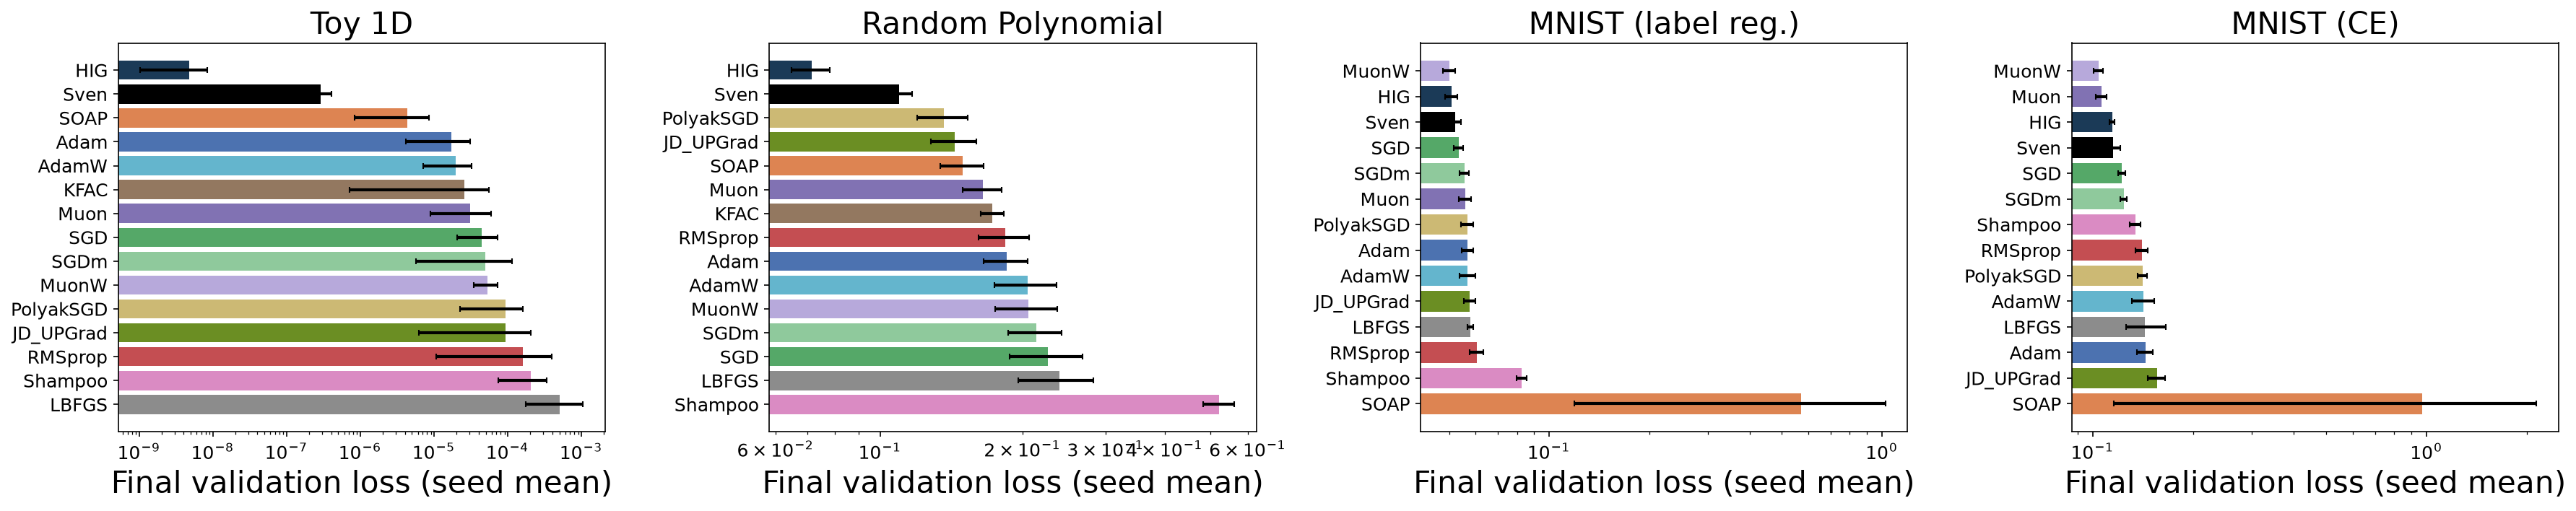

In [3]:
fig, axes = plt.subplots(1, len(tables), figsize=(6 * len(tables), 5), squeeze=False)
for ax, (key, t) in zip(axes[0], tables.items()):
    t = t.sort_values(METRIC)
    ax.barh(t['method'], t[METRIC], xerr=clipped_yerr(t[METRIC], t[f'{METRIC}_std'], t[f'{METRIC}_min']),
            capsize=2, color=[method_color(m) for m in t['method']])
    ax.set_xscale('log'); ax.invert_yaxis()
    ax.set_title(scans[key].title)
    ax.set_xlabel(metric_label(METRIC))
fig.tight_layout()
fig.savefig(PLOT_DIR / 'best_loss_by_optimizer.pdf', bbox_inches='tight')
plt.show()

## 3. Table

In [4]:
cols = ['method', 'config', 'n_seeds', 'n_diverged', METRIC, f'{METRIC}_std',
        'final_val_loss' if METRIC != 'final_val_loss' else 'final_train_loss']
for key, t in tables.items():
    print(f'== {scans[key].title} ==  (best config per optimizer by seed-mean {METRIC})')
    print(t[[c for c in cols if c in t]].to_string(index=False, float_format=lambda v: f'{v:.3e}'))
    print()

== Toy 1D ==  (best config per optimizer by seed-mean final_val_loss)
   method                                           config  n_seeds  n_diverged  final_val_loss  final_val_loss_std  final_train_loss
      HIG                              lr=0.005, tau=1e-06        5           0       4.707e-09           3.677e-09         5.216e-09
     Sven                       k=32, lr=0.01, rtol=0.0001        5           0       2.873e-07           1.163e-07         3.030e-07
     SOAP                                         lr=0.001        5           0       4.325e-06           4.089e-06         4.944e-06
     Adam                                         lr=0.001        5           0       1.698e-05           1.363e-05         1.995e-05
    AdamW                      lr=0.001, weight_decay=0.01        5           0       1.948e-05           1.244e-05         2.652e-05
     KFAC                                         lr=0.001        5           0       2.552e-05           3.025e-05         3.